In [1]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [2]:
import glob
import xarray as xr
PATH = "/Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/*"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]


File 0: /Users/lb962/Documents/GitHub/ESL_stats/data/ml4_removed/station_1.nc
<xarray.Dataset> Size: 58MB
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 8B ...
  * valid_time           (valid_time) datetime64[ns] 6MB 1940-01-01 ... 2025-...
    latitude             float64 8B ...
    longitude            float64 8B ...
    station_latitude     float64 8B ...
    station_longitude    float64 8B ...
    year                 (valid_time) int64 6MB ...
Data variables: (12/15)
    u10                  (valid_time) float32 3MB ...
    v10                  (valid_time) float32 3MB ...
    d2m                  (valid_time) float32 3MB ...
    t2m                  (valid_time) float32 3MB ...
    msl                  (valid_time) float32 3MB ...
    sst                  (valid_time) float32 3MB ...
    ...                   ...
    mwp                  (valid_time) float32 3MB ...
    swh                  (valid_time) float32 3MB ...
    sea_level     

In [3]:
ds = xr.concat(datasets, dim='station')

# Bimonthly - select highest every 2 months
for independence

In [4]:
import warnings
warnings.filterwarnings("ignore")

In [5]:
import numpy as np
import xarray as xr

time_dim = "valid_time"
station_dim = "station"
var = "residual"

# 1) annual means per station
annual = ds[var].resample({time_dim: "YS"}).mean()

# 2) numeric years since first annual sample, centered for stability
t = xr.DataArray(
    (annual[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: annual[time_dim]},
)
t = t - t.mean(time_dim)

# 3) mask finite data
y = annual
mask = np.isfinite(y)

# 4) station-wise OLS slope/intercept using xarray algebra
t_masked = t.where(mask)
t_mean = t_masked.mean(time_dim)
y_mean = y.where(mask).mean(time_dim)

cov_ty = ((t - t_mean) * (y - y_mean)).where(mask).sum(time_dim)
var_t = ((t - t_mean) ** 2).where(mask).sum(time_dim)

slope = cov_ty / var_t
intercept = y_mean - slope * t_mean

# 5) evaluate trend on full original time axis
t_full = xr.DataArray(
    (ds[time_dim] - annual[time_dim].isel({time_dim: 0})) / np.timedelta64(1, "D") / 365.25,
    dims=time_dim,
    coords={time_dim: ds[time_dim]},
)
t_full = t_full - t.mean(time_dim)

trend_full = slope * t_full + intercept

# 6) save
ds[f"{var}_annual_mean"] = annual
ds[f"{var}_station_trend_per_year"] = slope
ds[f"{var}_station_intercept"] = intercept
ds[f"{var}_annual_linear_trend"] = trend_full
ds[f"{var}_annual_detrended"] = ds[var] - trend_full

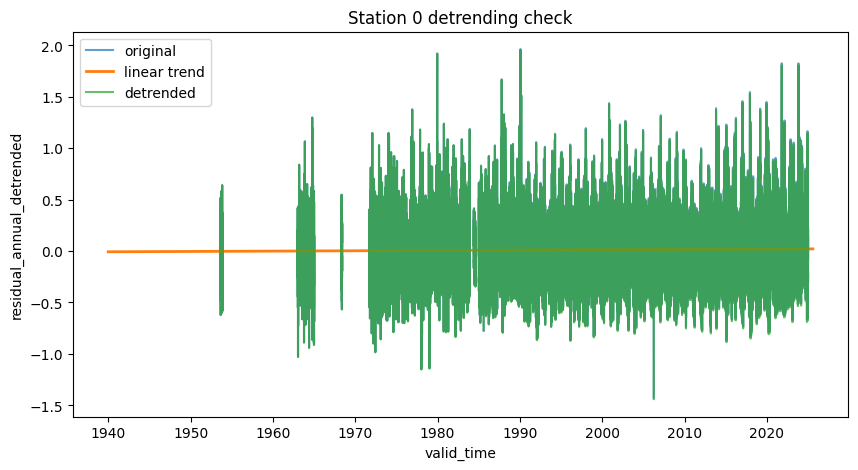

In [6]:
import matplotlib.pyplot as plt
st = ds.isel(station=290)   # or ds.sel(station=1) if labeled
plt.figure(figsize=(10,5))

st["residual"].plot(label='original', alpha=0.7)
st['residual_annual_linear_trend'].plot(label='linear trend', linewidth=2)
st['residual_annual_detrended'].plot(label='detrended', alpha=0.7)

plt.legend()
plt.title('Station 0 detrending check')
plt.show()

In [7]:
select_df = pd.read_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/4_independce/independent_stations.csv")

In [ ]:
import pandas as pd

# 1) Station lookup table from ds
station_lookup = pd.DataFrame({
    "station": ds["station"].values,
    "lat": ds["station_latitude"].values,
    "lon": ds["station_longitude"].values,
})
# 2) Keep only overlapping lat/lon pairs
overlap = station_lookup.merge(
    select_df[["lat", "lon"]].drop_duplicates(),
    on=["lat", "lon"],
    how="inner"
)

# 3) Extract matching station labels
stations_keep = overlap["station"].unique()

# 4) Subset ds only along station dimension
ds_filtered = ds.sel(station=stations_keep)

In [36]:
ds_filtered.to_netcdf("/Users/lb962/Documents/GitHub/ESL_stats/data/processed/selected_filter_stations.nc")

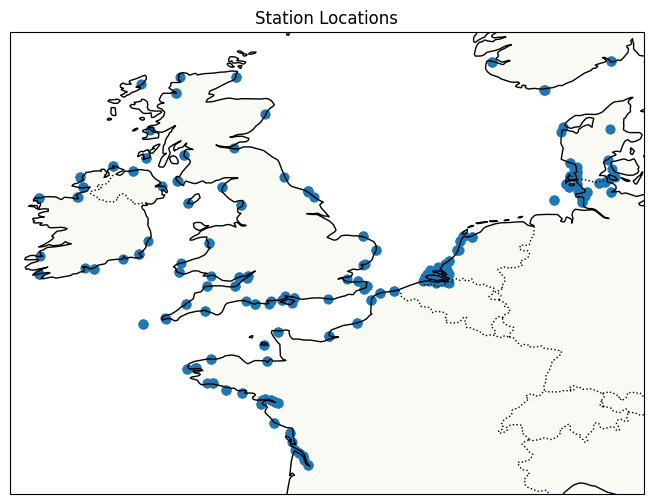

In [11]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

lats = ds_filtered["station_latitude"].values
lons = ds_filtered["station_longitude"].values

fig = plt.figure(figsize=(10, 6))
ax = plt.axes(projection=ccrs.PlateCarree())

# Add map features
ax.coastlines()
ax.add_feature(cfeature.LAND, alpha=0.3)
ax.add_feature(cfeature.BORDERS, linestyle=":")

# Scatter stations
ax.scatter(lons, lats, s=40, transform=ccrs.PlateCarree())

# Optional: zoom to region
ax.set_extent([
    lons.min() - 1, lons.max() + 1,
    lats.min() - 1, lats.max() + 1
])

plt.title("Station Locations")
plt.show()

In [27]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from scipy import stats as st
import pandas as pd
from sklearn.cluster import KMeans

# --- config ---
TARGET_VAR = 'residual_annual_detrended'
N_STATIONS = 295
CSV_OUT = "gev_fit_scores_msl.csv"
N_CLUSTERS = 3

if TARGET_VAR not in ds_filtered.data_vars:
    for v in ds_filtered.data_vars:
        if np.issubdtype(ds_filtered[v].dtype, np.number):
            TARGET_VAR = v
            print(f"Using variable '{TARGET_VAR}' (first numeric data variable).")
            break
    else:
        raise ValueError("No numeric data variable found to fit.")

def _meta_for_station(i):
    lat = None
    lon = None
    try:
        lat = float(ds_filtered["station_latitude"].sel(station=i))
        lon = float(ds_filtered["station_longitude"].sel(station=i))
    except Exception:
        try:
            lat = float(ds_filtered["latitude"])
            lon = float(ds_filtered["longitude"])
        except Exception:
            pass
    return lat, lon

def _time_dim(da):
    candidates = [d for d in da.dims if d not in ("station", "stations")]
    if not candidates:
        raise ValueError("Could not infer time dimension.")
    return candidates[0]

def kuiper_statistic(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / n
    F_mod = cdf_func(x)
    D_plus = np.max(F_emp - F_mod)
    D_minus = np.max(F_mod - (i - 1) / n)
    return D_plus + D_minus

def r2_cdf_fit(x, cdf_func):
    x = np.sort(np.asarray(x))
    n = x.size
    i = np.arange(1, n + 1)
    F_emp = i / (n + 1.0)
    F_mod = cdf_func(x)
    ss_res = np.sum((F_emp - F_mod) ** 2)
    ss_tot = np.sum((F_emp - np.mean(F_emp)) ** 2)
    if ss_tot == 0:
        return np.nan
    return 1 - ss_res / ss_tot

stations = np.array(ds["station"].values)[:N_STATIONS]

results = []

for s in stations:
    try:
        da = ds_filtered[TARGET_VAR].sel(station=s)
    except Exception:
        print(f"Skipping station {s}: not present in ds_filtered.")
        continue

    try:
        tdim = _time_dim(da)
    except Exception as e:
        print(f"Skipping station {s}: could not infer time dimension ({e}).")
        continue

    da = da.where(np.isfinite(da), drop=True)

    if da.size < 10:
        print(f"Skipping station {s}: not enough data after cleaning.")
        continue

    try:
        da_bi = da.resample({tdim: "2M"}).max()
    except Exception as e:
        print(f"Skipping station {s}: resample failed ({e}).")
        continue

    x = da_bi.values.ravel()
    x = x[np.isfinite(x)]

    if x.size < 5:
        print(f"Skipping station {s}: not enough bimonthly maxima ({x.size}).")
        continue

    try:
        gev_params = st.genextreme.fit(x)
        c, loc, scale = gev_params
    except Exception as e:
        print(f"Skipping station {s}: GEV fit failed ({e}).")
        continue

    def gev_cdf(z):
        return st.genextreme.cdf(z, c, loc=loc, scale=scale)

    try:
        ks_stat, ks_p = st.kstest(x, "genextreme", args=gev_params)
        kuiper = kuiper_statistic(x, gev_cdf)
        r2 = r2_cdf_fit(x, gev_cdf)
    except Exception as e:
        print(f"Skipping station {s}: GOF calculation failed ({e}).")
        continue

    lat, lon = _meta_for_station(s)

    results.append({
        "station": int(s),
        "lat": lat,
        "lon": lon,
        "n_blocks": int(x.size),
        "gev_c": c,
        "gev_loc": loc,
        "gev_scale": scale,
        "ks_stat": ks_stat,
        "ks_pvalue": ks_p,
        "kuiper": kuiper,
        "r2_cdf": r2,
    })

df = pd.DataFrame(results)

if df.empty:
    raise RuntimeError("No stations were successfully fitted. Check your data and config.")

df.to_csv(CSV_OUT, index=False)
print(f"Saved GEV fit parameters and scores to: {CSV_OUT}")

Skipping station 10: not present in ds_filtered.
Skipping station 103: not present in ds_filtered.
Skipping station 109: not present in ds_filtered.
Skipping station 110: not present in ds_filtered.
Skipping station 112: not present in ds_filtered.
Skipping station 113: not present in ds_filtered.
Skipping station 143: not present in ds_filtered.
Skipping station 145: not present in ds_filtered.
Skipping station 157: not present in ds_filtered.
Skipping station 159: not present in ds_filtered.
Skipping station 160: not present in ds_filtered.
Skipping station 163: not present in ds_filtered.
Skipping station 164: not present in ds_filtered.
Skipping station 165: not present in ds_filtered.
Skipping station 173: not present in ds_filtered.
Skipping station 21: not present in ds_filtered.
Skipping station 210: not present in ds_filtered.
Skipping station 254: not present in ds_filtered.
Skipping station 265: not present in ds_filtered.
Skipping station 266: not present in ds_filtered.
Sk

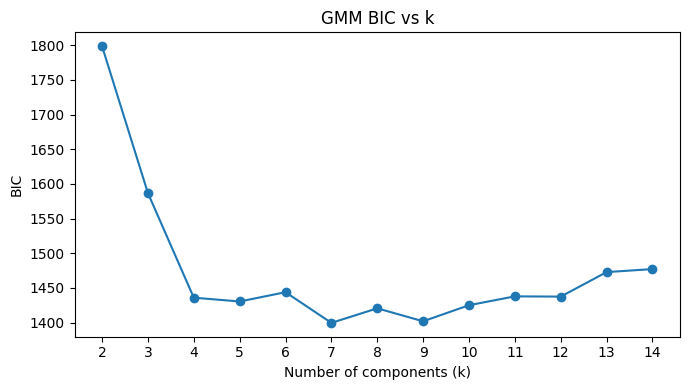

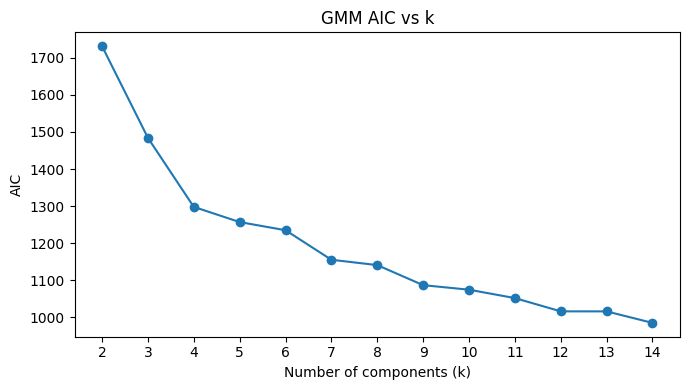

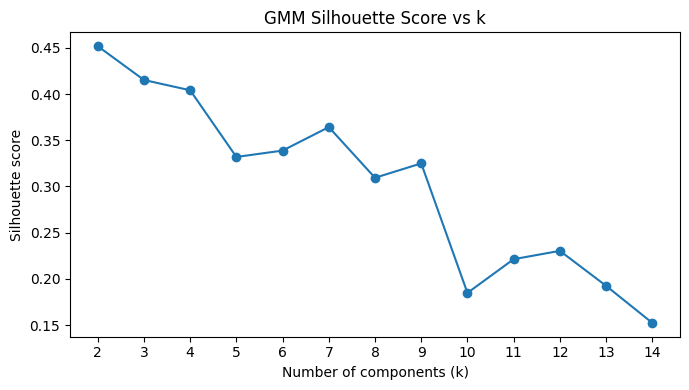

Best k by BIC: 7
Best k by AIC: 14
Best k by silhouette: 2
k= 2  BIC=1798.67  AIC=1731.38  silhouette=0.4518
k= 3  BIC=1586.74  AIC=1484.04  silhouette=0.4152
k= 4  BIC=1435.92  AIC=1297.81  silhouette=0.4041
k= 5  BIC=1430.41  AIC=1256.89  silhouette=0.3319
k= 6  BIC=1443.83  AIC=1234.90  silhouette=0.3388
k= 7  BIC=1399.56  AIC=1155.22  silhouette=0.3642
k= 8  BIC=1420.56  AIC=1140.80  silhouette=0.3094
k= 9  BIC=1401.88  AIC=1086.71  silhouette=0.3250
k=10  BIC=1425.05  AIC=1074.47  silhouette=0.1848
k=11  BIC=1437.82  AIC=1051.82  silhouette=0.2213
k=12  BIC=1437.47  AIC=1016.06  silhouette=0.2303
k=13  BIC=1472.80  AIC=1015.98  silhouette=0.1925
k=14  BIC=1477.17  AIC=984.94  silhouette=0.1524


In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]

# Align df to cleaned rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

# 5) Try a range of component counts
k_range = range(2, 15)

bic_scores = []
aic_scores = []
sil_scores = []

for k in k_range:
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=0,
        n_init=5
    )
    gmm.fit(Xs)
    labels = gmm.predict(Xs)

    bic_scores.append(gmm.bic(Xs))
    aic_scores.append(gmm.aic(Xs))

    # silhouette only valid if >1 cluster actually assigned
    if len(np.unique(labels)) > 1:
        sil_scores.append(silhouette_score(Xs, labels))
    else:
        sil_scores.append(np.nan)

# -----------------------------
# 1) BIC plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), bic_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of components (k)")
plt.ylabel("BIC")
plt.title("GMM BIC vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) AIC plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), aic_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of components (k)")
plt.ylabel("AIC")
plt.title("GMM AIC vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 3) Silhouette plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of components (k)")
plt.ylabel("Silhouette score")
plt.title("GMM Silhouette Score vs k")
plt.tight_layout()
plt.show()

# Best k
best_k_bic = list(k_range)[int(np.argmin(bic_scores))]
best_k_aic = list(k_range)[int(np.argmin(aic_scores))]
best_k_sil = list(k_range)[int(np.nanargmax(sil_scores))]

print("Best k by BIC:", best_k_bic)
print("Best k by AIC:", best_k_aic)
print("Best k by silhouette:", best_k_sil)

for k, bic, aic, sil in zip(k_range, bic_scores, aic_scores, sil_scores):
    print(f"k={k:2d}  BIC={bic:.2f}  AIC={aic:.2f}  silhouette={sil:.4f}")

In [48]:
best_k = best_k_bic   # or best_k_aic / best_k_sil

gmm = GaussianMixture(
    n_components=best_k,
    covariance_type="full",
    random_state=0,
    n_init=5
)

labels = gmm.fit_predict(Xs)

# start cluster numbering at 1
dfc["cluster"] = labels + 1

CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_gmm_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)

print(summary)

Saved clustered GEV parameters to: gev_fit_scores_msl_gmm_gev_k7.csv
        gev_c                               gev_loc                      \
        count      mean    median       std   count      mean    median   
cluster                                                                   
1          97  0.166379  0.156094  0.163238      97  0.921403  0.904397   
2          92 -0.000906  0.004512  0.077068      92  0.445896  0.438156   
3          11  1.060295  1.057000  0.081871      11  1.511483  1.506676   
4          38  0.078294  0.125465  0.275673      38  0.531279  0.501107   
5           2  0.382749  0.382749  0.364361       2  0.466378  0.466378   
6           3  1.028779  1.089404  0.260614       3  2.005814  1.865392   
7          12  0.658731  0.611122  0.289403      12  0.497299  0.515805   

                  gev_scale            ...   ks_stat           kuiper  \
              std     count      mean  ...    median       std  count   
cluster                           

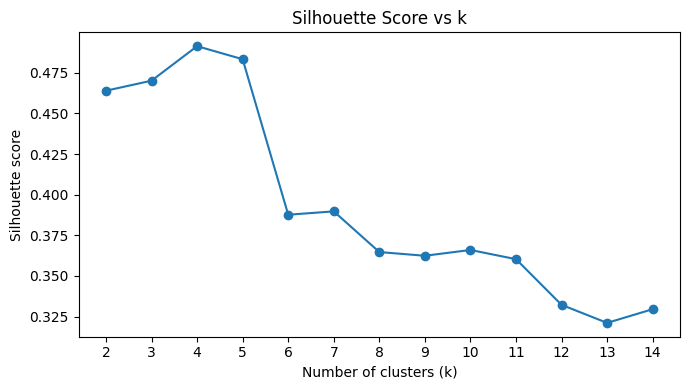

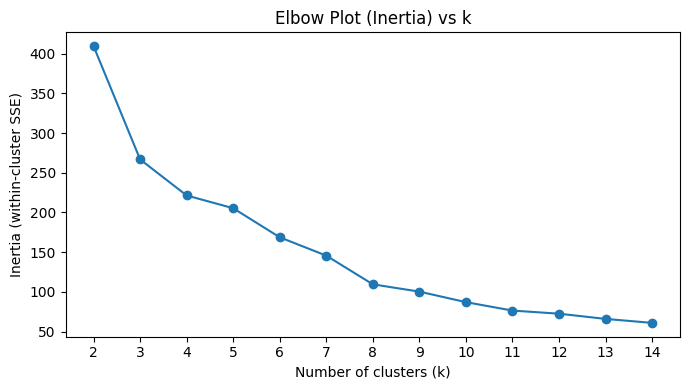

Best k by silhouette: 4
k= 2  silhouette=0.4640  inertia=409.33
k= 3  silhouette=0.4701  inertia=266.74
k= 4  silhouette=0.4914  inertia=221.39
k= 5  silhouette=0.4833  inertia=205.33
k= 6  silhouette=0.3877  inertia=168.73
k= 7  silhouette=0.3897  inertia=145.64
k= 8  silhouette=0.3647  inertia=109.54
k= 9  silhouette=0.3624  inertia=100.34
k=10  silhouette=0.3660  inertia=87.10
k=11  silhouette=0.3604  inertia=76.49
k=12  silhouette=0.3323  inertia=72.56
k=13  silhouette=0.3211  inertia=65.99
k=14  silhouette=0.3296  inertia=60.99


In [40]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1) Select GEV parameter features
feat_cols = ["gev_c", "gev_loc", "gev_scale"]
Xdf = df[feat_cols].apply(pd.to_numeric, errors="coerce")

# 2) Basic cleaning: drop rows with missing params, ensure valid scale
Xdf = Xdf.replace([np.inf, -np.inf], np.nan).dropna(axis=0, how="any")
Xdf = Xdf[Xdf["gev_scale"] > 0]  # scale must be positive

# Align df to Xdf rows
dfc = df.loc[Xdf.index].copy()

# 3) Light stabilization: log-transform scale (often highly skewed)
Xdf = Xdf.copy()
Xdf["gev_scale"] = np.log(Xdf["gev_scale"])

# 4) Standardize
scaler = StandardScaler()
Xs = scaler.fit_transform(Xdf.to_numpy(dtype=float))

k_range = range(2, 15)  # adjust upper bound if you want
sil_scores = []
inertias = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=0, n_init="auto")
    labels = km.fit_predict(Xs)

    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(Xs, labels))

# -----------------------------
# 1) Silhouette score plot
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), sil_scores, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Silhouette score")
plt.title("Silhouette Score vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# 2) Elbow plot (inertia)
# -----------------------------
plt.figure(figsize=(7, 4))
plt.plot(list(k_range), inertias, marker="o")
plt.xticks(list(k_range))
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia (within-cluster SSE)")
plt.title("Elbow Plot (Inertia) vs k")
plt.tight_layout()
plt.show()

# -----------------------------
# Optional: choose best k by silhouette
# -----------------------------
best_k_sil = list(k_range)[int(np.argmax(sil_scores))]
print("Best k by silhouette:", best_k_sil)

# Optional: print table for logging
for k, s, iner in zip(k_range, sil_scores, inertias):
    print(f"k={k:2d}  silhouette={s:.4f}  inertia={iner:.2f}")


In [44]:
# 6) Fit final KMeans
best_k = 4
km = KMeans(n_clusters=best_k, random_state=0, n_init="auto")
labels = km.fit_predict(Xs)

# 7) Attach cluster labels back to df
dfc["cluster"] = labels + 1

# 8) Save clustered table
CSV_OUT_CLUSTERED = CSV_OUT.replace(".csv", f"_kmeans_gev_k{best_k}.csv")
dfc.to_csv(CSV_OUT_CLUSTERED, index=False)
print(f"Saved clustered GEV parameters to: {CSV_OUT_CLUSTERED}")

# 9) Quick cluster summaries (in original parameter units)
summary = (
    dfc.groupby("cluster")[feat_cols + ["n_blocks", "ks_stat", "kuiper", "r2_cdf"]]
       .agg(["count", "mean", "median", "std"])
)

Saved clustered GEV parameters to: gev_fit_scores_msl_kmeans_gev_k4.csv


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

# Feature names (same order as used for fitting)
feat_cols = ["gev_c", "gev_loc", "gev_scale"]

# --------------------------------------------------
# 1. Get cluster centers in standardized space
# --------------------------------------------------
centers_std = km.cluster_centers_  # shape (k, 3)

# --------------------------------------------------
# 2. Invert standardization
# --------------------------------------------------
centers_unscaled = scaler.inverse_transform(centers_std)

# --------------------------------------------------
# 3. Undo log-transform on gev_scale
# --------------------------------------------------
centers_unscaled = centers_unscaled.copy()
centers_unscaled[:, 2] = np.exp(centers_unscaled[:, 2])

# --------------------------------------------------
# 4. Plot in ORIGINAL PARAMETER SPACE
# --------------------------------------------------
fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")

ax.scatter(
    centers_unscaled[:, 0],
    centers_unscaled[:, 1],
    centers_unscaled[:, 2],
    s=140,
    marker="o",
    depthshade=True,
)

# Label each cluster center
for i in range(centers_unscaled.shape[0]):
    ax.text(
        centers_unscaled[i, 0],
        centers_unscaled[i, 1],
        centers_unscaled[i, 2],
        f"  {i}",
        fontsize=10,
    )

ax.set_xlabel("gev_c")
ax.set_ylabel("gev_loc")
ax.set_zlabel("gev_scale")
ax.set_title(f"KMeans cluster centers in original GEV parameter space (k={best_k})")

plt.tight_layout()
plt.show()


AttributeError: 'GaussianMixture' object has no attribute 'cluster_centers_'

: 

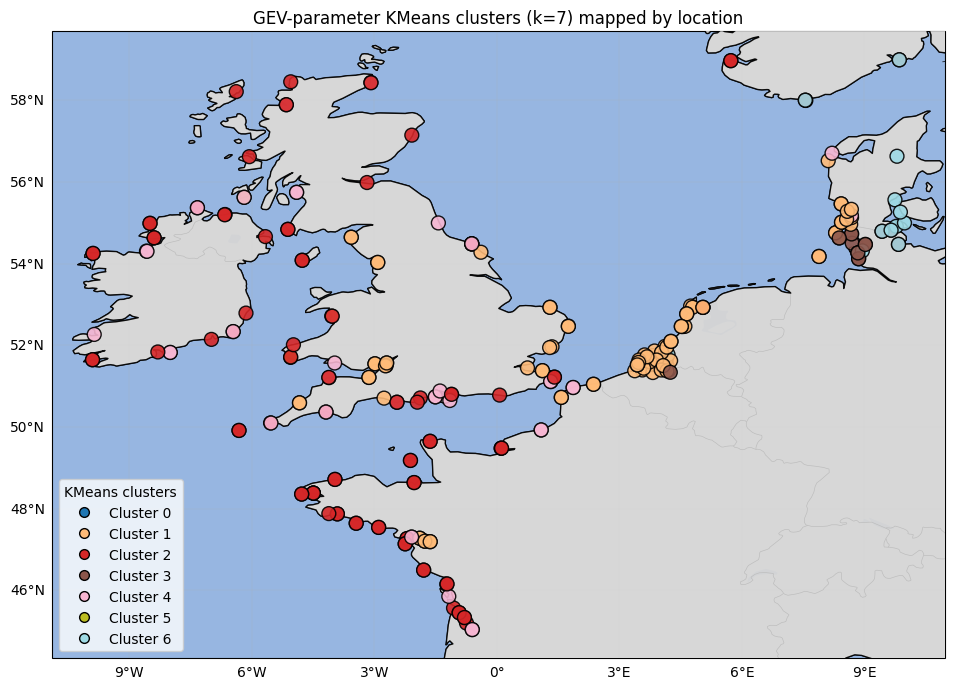

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# dfc must contain: lon, lat, cluster
# best_k is the number of clusters
assert {"lon", "lat", "cluster"}.issubset(dfc.columns)

# Ensure numeric lon/lat and drop missing
plotdf = dfc[["lon", "lat", "cluster"]].copy()
plotdf["lon"] = pd.to_numeric(plotdf["lon"], errors="coerce")
plotdf["lat"] = pd.to_numeric(plotdf["lat"], errors="coerce")
plotdf["cluster"] = pd.to_numeric(plotdf["cluster"], errors="coerce")
plotdf = plotdf.replace([np.inf, -np.inf], np.nan).dropna()

# If best_k not in scope, infer from data
k = int(plotdf["cluster"].nunique())

# --- Map setup ---
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(11, 7))
ax = plt.axes(projection=proj)

# Set extent with padding (optional but usually helpful)
lon_min, lon_max = plotdf["lon"].min(), plotdf["lon"].max()
lat_min, lat_max = plotdf["lat"].min(), plotdf["lat"].max()

pad_lon = max(0.5, 0.05 * (lon_max - lon_min))
pad_lat = max(0.5, 0.05 * (lat_max - lat_min))
ax.set_extent(
    [lon_min - pad_lon, lon_max + pad_lon, lat_min - pad_lat, lat_max + pad_lat],
    crs=ccrs.PlateCarree()
)

# Base features
ax.add_feature(cfeature.OCEAN, zorder=0)
ax.add_feature(cfeature.LAKES, alpha=0.5, zorder=1)
ax.add_feature(cfeature.BORDERS, linewidth=0.5, zorder=3)
ax.add_feature(cfeature.COASTLINE, linewidth=0.8, zorder=4)

# Categorical colors for clusters
cmap = cm.get_cmap("tab20", k) if k <= 20 else cm.get_cmap("gist_ncar", k)
norm = mcolors.BoundaryNorm(boundaries=np.arange(-0.5, k + 0.5, 1), ncolors=k)



# Land on top (so land masks points if you prefer). Adjust alpha as needed.
land = cfeature.NaturalEarthFeature(
    "physical", "land", "50m", facecolor="lightgray", edgecolor="black"
)
ax.add_feature(land, alpha=0.9, zorder=5)

# Optional: gridlines
gl = ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
gl.top_labels = False
gl.right_labels = False

# Legend (categorical)
# Build custom legend handles
handles = [
    plt.Line2D([0], [0], marker="o", linestyle="",
               markersize=7, markerfacecolor=cmap(i), markeredgecolor="k",
               label=f"Cluster {i}")
    for i in range(k)
]

# Scatter points (clusters)
sc = ax.scatter(
    plotdf["lon"].values,
    plotdf["lat"].values,
    c=plotdf["cluster"].values,
    cmap=cmap,
    norm=norm,
    s=100,
    zorder=40,
    alpha=0.9,
    transform=ccrs.PlateCarree(),
    edgecolors='black')
ax.set_title(f"GEV-parameter KMeans clusters (k={k}) mapped by location")
ax.legend(handles=handles, title="KMeans clusters", loc="lower left", frameon=True)
plt.tight_layout()
plt.show()


In [35]:
dfc.to_csv("/Users/lb962/Documents/GitHub/ESL_stats/notebooks/C_KDE/station_GEV_4_msl.csv")